In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

df_customer = pd.read_csv('../data/processed/online_retail_with_customer.csv')
df_customer['InvoiceDate'] = pd.to_datetime(df_customer['InvoiceDate'])
print(df_customer.shape)
df_customer.head()

(776606, 11)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,Revenue,Category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,83.4,Christmas & Seasonal
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.0,Home Decor & Lighting
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,81.0,Home Decor & Lighting
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,100.8,Home Decor & Lighting
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,30.0,Storage & Boxes


## Feature Engineering: RFM + Customer Lifetime Value (historical)

In [2]:
customer_features = df_customer.groupby('Customer ID').agg(
    Monetary=('Revenue', 'sum'),
    Frequency=('Invoice', 'nunique'),
    days_since_last_purchase=('InvoiceDate', lambda x: (df_customer['InvoiceDate'].max() - x.max()).days))

customer_features.columns = ['Monetary', 'Frequency', 'days_since_last_purchase']
customer_features['customer_lifetime_value'] = customer_features['Monetary']

customer_features.describe()

,Monetary,Frequency,days_since_last_purchase,customer_lifetime_value
count,5852.000000,5852.000000,5852.000000,5852.000000
mean,2916.747904,6.254956,199.198052,2916.747904
std,14307.046290,12.749386,208.509570,14307.046290
min,2.950000,1.000000,0.000000,2.950000
25%,339.575000,1.000000,24.000000,339.575000
50%,856.020000,3.000000,94.000000,856.020000
75%,2241.030000,7.000000,378.000000,2241.030000
max,580987.040000,373.000000,738.000000,580987.040000


## Feature Selection: Correlation Heatmap

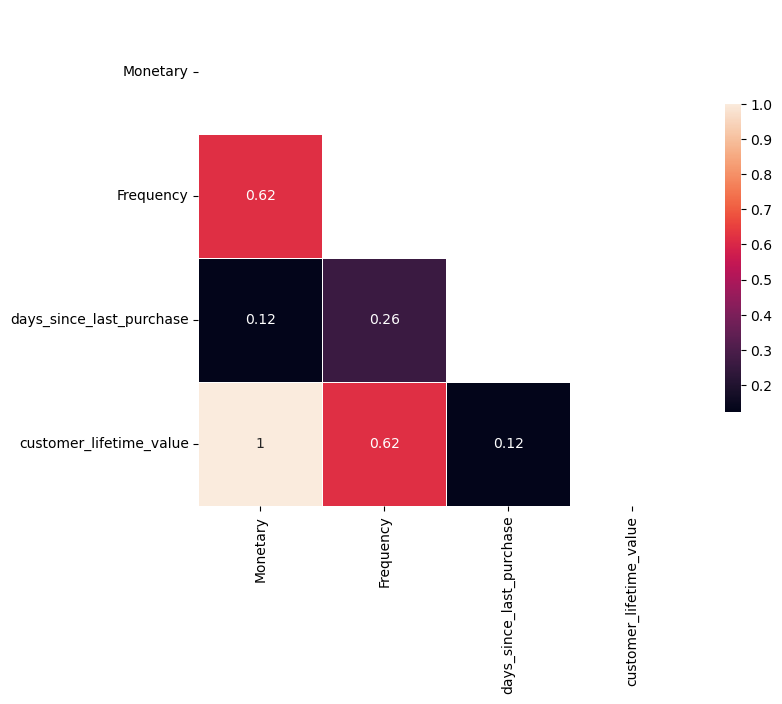

In [3]:
corr = np.abs(customer_features.corr())

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(8, 8))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=corr)

plt.show()

## Train/Test Split + Normalization

In [5]:
features = customer_features[['Frequency', 'days_since_last_purchase']]
target = customer_features['customer_lifetime_value']

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=0)

normalizer = MinMaxScaler()
normalizer.fit(x_train)

x_train_norm = normalizer.transform(x_train)
x_test_norm = normalizer.transform(x_test)
x_train_norm[:5]

array([[0.00268817, 0.40162822],
       [0.02150538, 0.04748982],
       [0.        , 0.52510176],
       [0.00537634, 0.02849389],
       [0.00268817, 0.17096336]])

## Baseline KNN Regressor

In [6]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

knn = KNeighborsRegressor()
knn.fit(x_train_norm, y_train)

pred_baseline = knn.predict(x_test_norm)

print("MAE", mean_absolute_error(pred_baseline, y_test))
print("RMSE", root_mean_squared_error(pred_baseline, y_test))
print("R2 score", knn.score(x_test_norm, y_test))

MAE 1679.6524978650727
RMSE 10644.985665632355
R2 score 0.6543976865745369


## Feature Selection Test
Testing whether removing the weakly-correlated days_since_last_purchase feature (r=0.12 with target) improves or hurts performance

In [7]:
x_train_norm_df = pd.DataFrame(x_train_norm, columns=features.columns)
x_test_norm_df = pd.DataFrame(x_test_norm, columns=features.columns)

knn_reduced = KNeighborsRegressor()
knn_reduced.fit(x_train_norm_df[['Frequency']], y_train)

print("Full features R2:", knn.score(x_test_norm, y_test))
print("Frequency-only R2:", knn_reduced.score(x_test_norm_df[['Frequency']], y_test))

Full features R2: 0.6543976865745369
Frequency-only R2: 0.6146152919267089


**Finding:** removing `days_since_last_purchase` reduced performance from 0.6544 to 0.6146, confirming both features contribute meaningfully despite one of them have a  weak individual correlation with the target. Both features are kept in the final model.

## Hyperparameter Tuning: GridSearchCV

In [9]:
knn_model = KNeighborsRegressor()

grid = {"n_neighbors": [3, 5, 10, 15, 20]}

model = GridSearchCV(estimator=knn_model, param_grid=grid, cv=5)
model.fit(x_train_norm, y_train)

model.best_params_

{'n_neighbors': 15}

In [10]:
from sklearn.metrics import root_mean_squared_error

best_model = model.best_estimator_
pred_tuned = best_model.predict(x_test_norm)

print("Best n_neighbors:", model.best_params_)
print("MAE", mean_absolute_error(pred_tuned, y_test))
print("RMSE", root_mean_squared_error(pred_tuned, y_test))
print("R2 score", best_model.score(x_test_norm, y_test))

Best n_neighbors: {'n_neighbors': 15}
MAE 1787.7139607742672
RMSE 13849.409599452527
R2 score 0.4150092504481233


## Inspecting the Tuned Model's Errors

The GridSerachCV model (n_neighbors=15) performed worse on the test set (R2 score 0.415) than the untuned baseline (R2 score 0.65). Before accepting GridSerachCV's result as final, we inspect where do the largest errors occur.

In [11]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': pred_tuned})
comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison.sort_values('Error', key=abs, ascending=False).head(5)

,Actual,Predicted,Error
Customer ID,,,
14646,526751.52,118604.820800,408146.699200
14156,303069.88,118604.820800,184465.059200
12971,15704.60,107287.173467,-91582.573467
14088,64036.80,7259.097333,56777.702667
17961,2866.74,58712.201467,-55845.461467


**Finding:** the biggest prediction errors belong to the highest value customers. With n_neighbors=15, each prediction is based on the 15 closest   customers. This means a very high spending customer's prediction gets pull down toward the average of more typical customers nearby, making the prediction much lowers than the real value. GridSearchCV select the setting that handles rare, extreme customers well. Thats why the best setting it chose didnt actually work well for our small number of very high spending cusotmers.

## Final Model Selection

GridSearchCV chose n_neighbors=15 as the best setting, based on testing during cross validation. But when tested this model on held out test data, it performed worse than the simple baseline model. The main reason was poor predictions for high value customers. Beacause of this, in this project the baseline KNN model (n_neighbors) was chosen as final model since it worked better in practice, even though it wasn't GridSerchCV's top pick. This is an important finding on its own, automated tuning tools like GridSearchCV pick the setting that performs best on average, they don't guarantee the best result for every situation, especially with a small, uneven dataset like this project (5852 customers, including a few extreme high spenders).


In [13]:
final_model = KNeighborsRegressor()
final_model.fit(x_train_norm, y_train)

pred_final = final_model.predict(x_test_norm)

print("MAE", mean_absolute_error(pred_final, y_test))
print("RMSE", root_mean_squared_error(pred_final, y_test))
print("R2 score", final_model.score(x_test_norm, y_test))

MAE 1679.6524978650727
RMSE 10644.985665632355
R2 score 0.6543976865745369


## Model Comparison
To strenghen the machine learning analysis, two additional regression models are tested and compared with the KNN Regressor. The same training and testing data are used for all models so that performance can be compared fairly. 
The compared models are:
KNN Regressor
Linear Regression
Decision Tree Regressor

Performance is evaluated using MAE, RMSE and R2.

### Linear Regression
Linear Regression is used as a simple baseline model. It assumes a linear relationship between the customer behavior feature and historical customer lifetime value.

In [14]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(x_train_norm, y_train)

pred_linear = linear_model.predict(x_test_norm)

linear_mae = mean_absolute_error(y_test, pred_linear)
linear_rmse = root_mean_squared_error(y_test, pred_linear)
linear_r2 = linear_model.score(x_test_norm, y_test)

print("Linear Regression")
print("MAE", linear_mae)
print("RMSE", linear_rmse)
print("R2 score:", linear_r2)

Linear Regression
MAE 2108.867976857893
RMSE 14758.519283753616
R2 score: 0.33568806782042704


### Desicion Tree Regressor
Decision Tree Regressor is tested because it can capture non-linear relationships between customer purchasing behavior and customer lifetime value.

In [20]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=10, random_state=0)

tree_model.fit(x_train_norm, y_train)

pred_tree = tree_model.predict(x_test_norm)

tree_mae = mean_absolute_error(y_test, pred_tree)
tree_rmse = root_mean_squared_error(y_test, pred_tree)
tree_r2 = tree_model.score(x_test_norm, y_test)

print("Descison Tree Regressor")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R2 score:", tree_r2)

Descison Tree Regressor
MAE: 1908.2154084879144
RMSE: 16707.415094367836
R2 score: 0.1486561471833847


In [22]:
knn_mae = mean_absolute_error(y_test, pred_final)
knn_rmse = root_mean_squared_error(y_test, pred_final)
knn_r2 = final_model.score(x_test_norm, y_test)

In [24]:
model_comparison = pd.DataFrame({
    'Model': ['KNN Regressor', 'Linear Regression', 'Decision Tree Regressor'], 
    'MAE': [knn_mae, linear_mae, tree_mae],
    'RMSE': [knn_rmse, linear_rmse, tree_rmse],
    'R2 Score': [knn_r2, linear_r2, tree_r2]})

model_comparison.round(3)

,Model,MAE,RMSE,R2 Score
0,KNN Regressor,1679.652,10644.986,0.654
1,Linear Regression,2108.868,14758.519,0.336
2,Decision Tree Regressor,1908.215,16707.415,0.149


### Model Comparison Findings
Three regression models were compared using the same training and test data:
KNN Reegresor, linear Regression and Decison Tree Regressor.

KNN Regressor performed best across all three evaluation metrics. It achieved the lowest MAE (£1,679,65), the lowest RMSE (£10,644,99) and the highest R2 score (0.654).

Linear Regression achieved an R2 socre of 0.336, whike the Decision Tree Regressor achieved 0.149.

These results show that KNN is better suited to the relationships in this cusotmer dataset than the Linear Regression and Desicion Tree models tested. 
Therefore, KNN remains the selected moded for predicting historical customer lifetime value. 

## 9. Machine Learning Findings

A regression approach used to predict historical customer lifetime value (CLV) from customer purchasing behavior. The model used Frequency and days_since_last_purchase as features, with an 80/20 train-test split. MinMaxScaler was fitted only on the training data and then applied to both the training and test sets to prevent data leakage.

### Baseline KNN Performance

The baseline KNN Regressor (default n_neighbors=5) achieved:

- MAE: £1,679.65
- RMSE: £10,644.99
- R2: 0.654

The R2 score indicates that the model explains approximately 65.4% of the variation in historical customer lifetime value.

### Feature Selection

The correlation between days_since_last_purchase and CLV was relatively weak. To test whether this feature was useful, the KNN model was retrained using only Frequency.

Removing days_since_last_purchase reduced the R2 score from 0.654 to approximately 0.615. Therefore, both features were retained because the model performed better when both were included.

### Hyperparameter Tuning

GridSearchCV with 5-fold cross validation was used to test different values of n_neighbors.

GridSearchCV selected n_neighbors=15. However, when this tuned model was evaluated on the held-out test set, its R2 score dropped to approximately 0.415.

Further investigation showed that the largest prediction errors occurred among the highest value customers. Increasing the number of neighbors caused predictions for these unusual high spending customers to be pulled toward the values of more typical customers.

Therefore, the baseline KNN model with n_neighbors=5 was retained rather than the GridSearchCV selected model.

### Model Comparison

Three regression models were evaluated using the same training and test data:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| KNN Regressor | £1,679.65 | £10,644.99 | 0.654 |
| Linear Regression | £2,108.87 | £14,758.52 | 0.336 |
| Decision Tree Regressor | £1,908.22 | £16,707.42 | 0.149 |

KNN performed best across all three evaluation metrics. It produced the lowest MAE and RMSE and the highest R2 score.

The weaker performance of Linear Regression suggests that the relationship between customer purchasing behavior and CLV is not well represented by a simple linear relationship. The Decision Tree tested also performed substantially worse than KNN on unseen test data.

### Final Model

Based on the test set results, the KNN Regressor with n_neighbors=5 was selected as the final model.

The model provides useful predictive information about historical customer value, but its performance is weaker for the small number of extremely high value customers. This is an important limitation when using the model for business decisions.

Overall, the results suggest that customer purchase frequency and recency contain meaningful information about customer value, while also showing that extreme high value customers are more difficult to predict accurately.